In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import cohen_kappa_score

from scipy.stats import pearsonr

from tqdm import tqdm

from PyPDF2 import PdfReader
import re
from sklearn.metrics.pairwise import cosine_similarity



In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 8                  
EPOCHS = 10                      
PATIENCE = 3    
LEARNING_RATE = 2e-5
MAX_LENGTH = 384
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(DEVICE)

cuda


In [ ]:
df = pd.read_csv(
    "../../../data/processing/task1_ielts_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Total essays:", len(df))
df.head(10)


Total essays: 8548


,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates a comparsion of differ...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,249
1,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates the acid level in the ...,NaN,NaN,NaN,NaN,7.0,NaN,NaN,254
2,Line Graph,"Eating sweet foods produces acid in the mouth,...",The line graph depicts how a decay can appear ...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,176
3,Table,Percentage of UK people who consumed daily rec...,The bar chart illustrates the rate of people w...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,223
4,Table,Percentage of UK people who consumed daily rec...,The bar chart shed light on the proportions of...,NaN,NaN,NaN,NaN,7.5,NaN,NaN,213
5,Table,Percentage of UK people who consumed daily rec...,The bar graph compares the proportion of UK ci...,NaN,NaN,NaN,NaN,6.0,NaN,NaN,166
6,Table,Percentage of UK people who consumed daily rec...,The graph illustrates the percentage of fruit ...,NaN,NaN,NaN,NaN,5.5,NaN,NaN,175
7,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart illustrates the percentage of Au...,NaN,NaN,NaN,NaN,6.5,NaN,NaN,174
8,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart presents the information that th...,NaN,NaN,NaN,NaN,4.5,NaN,NaN,180
9,Multiple Graphs,The Pie chart gives information about the coun...,"There are many people lives in Australia,but t...",NaN,NaN,NaN,NaN,3.5,NaN,NaN,141


In [4]:
criteria_cols = ["Task_Achievement", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]
df_task1 = df.copy()

df_task1["Overall_Clean"] = df_task1["Overall"].astype(float)


In [5]:
df_full = df_task1.dropna(subset=criteria_cols)
df_missing = df_task1[df_task1[criteria_cols].isna().any(axis=1)]
print("Full labeled:", len(df_full))
print("Missing:", len(df_missing))

Full labeled: 8063
Missing: 485


In [6]:
df[df["Task_Achievement"].isna()][
    ["Task_Achievement", "Coherence_Cohesion", 
     "Lexical_Resource", "Range_Accuracy"]
].isna().sum()

Task_Achievement      485
Coherence_Cohesion    485
Lexical_Resource      485
Range_Accuracy        485
dtype: int64

In [7]:
print("\nDESCRIBE FULL")
print(df_full[criteria_cols + ["Overall"]].describe())

print("\nDESCRIBE MISSING")
print(df_missing["Overall"].describe())

df_full["criteria_mean"] = df_full[criteria_cols].mean(axis=1)

print("\nCorrelation mean(criteria) vs Overall:")
print(pearsonr(df_full["criteria_mean"], df_full["Overall"]))

print("\nMAE consistency:")
print(mean_absolute_error(df_full["criteria_mean"], df_full["Overall"]))


DESCRIBE FULL
       Task_Achievement  Coherence_Cohesion  Lexical_Resource  Range_Accuracy  \
count       8063.000000         8063.000000       8063.000000     8063.000000   
mean           6.940469            6.384410          6.350490        6.255426   
std            1.263794            1.677158          1.550082        1.887601   
min            4.000000            3.000000          3.000000        3.000000   
25%            6.000000            5.000000          5.000000        4.500000   
50%            7.000000            6.500000          6.500000        6.000000   
75%            8.000000            8.000000          7.500000        8.000000   
max            9.000000            9.000000          9.000000        9.000000   

           Overall  
count  8063.000000  
mean      6.574166  
std       1.523126  
min       4.000000  
25%       5.000000  
50%       6.500000  
75%       8.000000  
max       9.000000  

DESCRIBE MISSING
count    485.000000
mean       6.321649
std     

In [8]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal < 0.75:   
        return integer + 0.5
    else:
        return integer + 1

In [9]:
mean_criteria = df_full[criteria_cols].mean(axis=1).apply(round_band)
diff = np.abs(mean_criteria - df_full["Overall_Clean"])

print("Mean diff:", diff.mean())
print("Within 0.5:", np.mean(diff <= 0.5))


Mean diff: 0.0
Within 0.5: 1.0


In [10]:
reader = PdfReader("ielts_writing_band_descrips.pdf")

pdf_text = ""

for page in reader.pages:
    pdf_text += page.extract_text() + "\n"


print(pdf_text[:1000])

Writing Band 
Descriptors
Updated May 2023
Please visit IELTS.org for updates
2
Writing Task 1 
Band Descriptors
Updated May 2023
Please visit IELTS.org for updates
Page 1
Band
ScoreTask Achievement Coherence & Cohesion Lexical Resource Grammatical Range & 
Accuracy
9All the requirements of the task are fully and appropriately satisfied.
There may be extremely rare lapses in content.The message can be followed effortlessly.
Cohesion is used in such a way that it very 
rarely attracts attention.
Any lapses in coherence or cohesion are 
minimal.
Paragraphing is skilfully managed.Full flexibility and precise use are evident 
within the scope of the task.
A wide range of vocabulary is used accurately 
and appropriately with very natural and 
sophisticated control of lexical features.
Minor errors in spelling and word formation 
are extremely rare and have minimal impact 
on communication.A wide range of structures within the scope 
of the task is used with full flexibility and 
control.
Pu

In [11]:
def split_text(text, max_length=300):

    sentences = re.split(r'(?<=[.!?]) +', text)

    chunks = []
    current = ""

    for sent in sentences:
        if len(current) + len(sent) < max_length:
            current += " " + sent
        else:
            chunks.append(current.strip())
            current = sent

    if current:
        chunks.append(current.strip())

    return chunks

pdf_chunks = split_text(pdf_text)

print("Num PDF chunks:", len(pdf_chunks))

Num PDF chunks: 47


In [12]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [13]:
bert_rag = BertModel.from_pretrained("bert-base-uncased").to(DEVICE)
bert_rag.eval()

def get_embedding(text_list):

    encoded = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = bert_rag(
            input_ids=encoded["input_ids"].to(DEVICE),
            attention_mask=encoded["attention_mask"].to(DEVICE)
        )

    hidden = outputs.last_hidden_state

    pooled = (hidden * encoded["attention_mask"].unsqueeze(-1).to(DEVICE)).sum(dim=1) / \
             encoded["attention_mask"].sum(dim=1, keepdim=True).to(DEVICE)

    return pooled.cpu().numpy()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
pdf_embeddings = get_embedding(pdf_chunks)

In [15]:
def chunk_essay(essay, chunk_size=120):

    words = essay.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)

    return chunks

In [16]:
def retrieve_rag(essay):

    essay_chunks = chunk_essay(essay)

    essay_embeds = get_embedding(essay_chunks)

    rag_text = ""

    for emb in essay_embeds:

        sims = cosine_similarity([emb], pdf_embeddings)[0]

        top_idx = np.argsort(sims)[-2:]

        for idx in top_idx:
            rag_text += pdf_chunks[idx] + " "

    return rag_text

In [17]:
df_full["rag_text"] = df_full["Essay"].apply(retrieve_rag)

df_full["input_text"] = (   # Combine all relevant info into a single string
    "Overall Score: " + df_full["Overall"].astype(str) +
    " | Topic: " + df_full["Topic"].astype(str) +
    " | Word count: " + df_full["length"].astype(str) +
    " | Question: " + df_full["Question"].astype(str) +
    " [SEP] " +
    df_full["rag_text"]
)

In [18]:
encoded_inputs = tokenizer(
    df_full["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_masks = encoded_inputs["attention_mask"]

In [19]:
criteria = df_full[criteria_cols].values / 9.0
overall = df_full["Overall"].values / 9.0

criteria = torch.tensor(criteria, dtype=torch.float32)
overall = torch.tensor(overall, dtype=torch.float32)

In [20]:
indices = np.arange(len(df_full))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

6450 806 807


In [21]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    criteria[train_idx],
    overall[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    criteria[val_idx],
    overall[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_masks[test_idx],
    criteria[test_idx],
    overall[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [22]:
class BertChunkingMultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = BertModel.from_pretrained("bert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        hidden = self.encoder.config.hidden_size

        self.criteria_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

        self.overall_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        pooled = (hidden * attention_mask.unsqueeze(-1)).sum(dim=1) / \
                 attention_mask.sum(dim=1, keepdim=True)

        pooled = self.dropout(pooled)

        criteria = self.criteria_head(pooled)
        overall = self.overall_head(pooled).squeeze(1)

        return criteria, overall

In [23]:
model = BertChunkingMultiHead().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [25]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [26]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, masks, crit, overall in tqdm(train_loader):

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)
        crit = crit.to(DEVICE)
        overall = overall.to(DEVICE)

        optimizer.zero_grad()

        crit_pred, overall_pred = model(ids, masks)


        loss_criteria = criterion(crit_pred, crit)
        loss_overall = criterion(overall_pred, overall)

        loss_consistency = criterion(
            crit_pred.mean(dim=1),
            overall
        )

        loss = (
            0.5 * loss_criteria +
            0.3 * loss_overall +
            0.2 * loss_consistency
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for ids, masks, crit, overall in val_loader:

            ids = ids.to(DEVICE)
            masks = masks.to(DEVICE)
            overall = overall.to(DEVICE)

            _, overall_pred = model(ids, masks)

            loss = criterion(overall_pred, overall)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)

    logs.append({
        "epoch": epoch+1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "bertchunking_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break




Epoch 1/10


100%|██████████| 807/807 [00:42<00:00, 18.93it/s]


Train Loss: 0.0758858455940527
Val Loss: 0.00214395767462781

Epoch 2/10


100%|██████████| 807/807 [00:42<00:00, 18.91it/s]


Train Loss: 0.007578777350702288
Val Loss: 0.0011883199596454822

Epoch 3/10


...

Train Loss: 0.004111933098099618
Val Loss: 9.534739712924618e-05

Epoch 9/10


100%|██████████| 807/807 [00:42<00:00, 18.81it/s]


Train Loss: 0.003951664153968885
Val Loss: 0.00013791924983805903

Epoch 10/10


100%|██████████| 807/807 [00:42<00:00, 18.93it/s]


Train Loss: 0.0039139835983618655
Val Loss: 0.00025276573879718045


In [27]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("training_logs_bertchunking.csv", index=False)

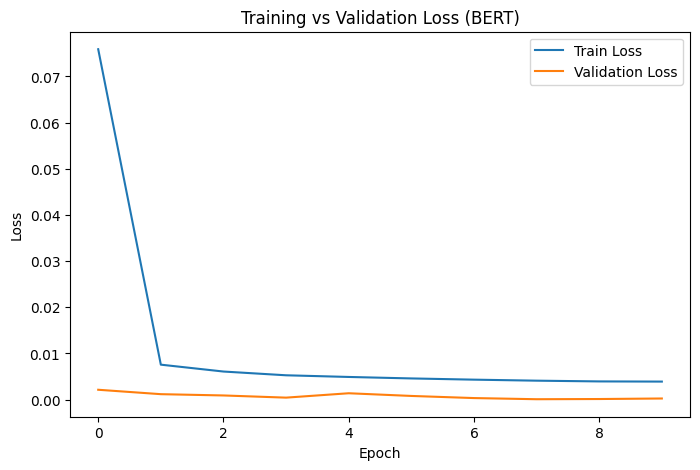

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (BERT)")
plt.legend()

plt.show()

In [29]:
model.load_state_dict(torch.load("bertchunking_model.pt", map_location=DEVICE))
model.eval()

BertChunkingMultiHead(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

In [30]:
all_criteria = []
all_overall = []
all_true = []

with torch.no_grad():

    for ids, masks, crit, overall in test_loader:

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)

        crit_pred, overall_pred = model(ids, masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        all_criteria.append(crit_pred.cpu().numpy())
        all_overall.append(overall_pred.cpu().numpy())
        all_true.append(overall.cpu().numpy())

all_criteria = np.vstack(all_criteria) * 9
overall_pred = np.concatenate(all_overall) * 9
overall_true = np.concatenate(all_true) * 9

In [31]:
vectorized_round = np.vectorize(round_band, otypes=[float])

In [32]:
print(overall_pred[:20])
print(vectorized_round(overall_pred)[:20])

[5.9871507 4.353413  6.5041347 7.0391016 8.058653  4.3418164 4.3093014
 8.049597  4.3052506 7.49666   5.4054604 6.4728494 7.4681125 8.042281
 8.532539  6.0426087 8.049497  4.3550186 4.9173474 7.050028 ]
[6.  4.5 6.5 7.  8.  4.5 4.5 8.  4.5 7.5 5.5 6.5 7.5 8.  8.5 6.  8.  4.5
 5.  7. ]


In [33]:
mae = mean_absolute_error(overall_true, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_true, overall_pred))
pearson = pearsonr(overall_true, overall_pred)[0]

within_half = np.mean(np.abs(overall_pred - overall_true) <= 0.5)

true_band = np.round(overall_true * 2).astype(int)
pred_band = np.round(overall_pred * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.06649190187454224
RMSE: 0.0903353819354547
Pearson: 0.9993456
Within ±0.5: 1.0
QWK: 0.999089853485584


In [34]:
criteria_mean = all_criteria.mean(axis=1)

print("\n===== CONSISTENCY CHECK =====")
print("MAE(mean(criteria), overall_true):",
      mean_absolute_error(overall_true, criteria_mean))

print("Pearson:",
      pearsonr(criteria_mean, overall_true)[0])


===== CONSISTENCY CHECK =====
MAE(mean(criteria), overall_true): 0.059858981519937515
Pearson: 0.99904513


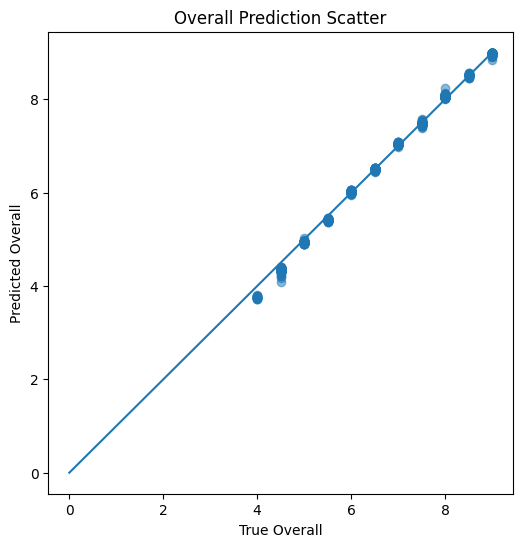

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(overall_true, overall_pred, alpha=0.5)

# đường y = x (perfect prediction)
plt.plot([0, 9], [0, 9])

plt.xlabel("True Overall")
plt.ylabel("Predicted Overall")
plt.title("Overall Prediction Scatter")

plt.show()

In [36]:

test_df = df_full.iloc[test_idx].copy().reset_index(drop=True)

overall_pred_rounded = vectorized_round(overall_pred)
criteria_rounded = vectorized_round(all_criteria)

test_df["overall_pred_raw"] = overall_pred
test_df["overall_pred"] = overall_pred_rounded

test_df["Task_Achievement_pred"] = all_criteria[:, 0]
test_df["Coherence_Cohesion_pred"] = all_criteria[:, 1]
test_df["Lexical_Resource_pred"] = all_criteria[:, 2]
test_df["Range_Accuracy_pred"] = all_criteria[:, 3]

test_df["Task_Achievement_pred_round"] = criteria_rounded[:, 0]
test_df["Coherence_Cohesion_pred_round"] = criteria_rounded[:, 1]
test_df["Lexical_Resource_pred_round"] = criteria_rounded[:, 2]
test_df["Range_Accuracy_pred_round"] = criteria_rounded[:, 3]

test_df["error_raw"] = test_df["overall_pred_raw"] - test_df["Overall"]
test_df["error_round"] = test_df["overall_pred"] - test_df["Overall"]

test_df["criteria_mean"] = all_criteria.mean(axis=1)
test_df["criteria_std"] = np.std(all_criteria, axis=1)

test_df.head(10)

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,...,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Achievement_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,error_raw,error_round,criteria_std
0,Table,Percentage of UK people who consumed daily rec...,Given is the chart comparing the ratio of the ...,6.5,5.5,5.5,5.5,6.0,6.0,**Task Achievement: [6.5]**\nThe report addres...,...,5.847583,5.947052,5.602659,7.0,6.0,6.0,5.5,-0.012849,0.0,0.444183
1,Map,The maps below shows university sports courts ...,The provided map depicts the university sports...,5.0,4.0,4.0,4.0,4.5,4.5,**Task Achievement: [5]**\nThe main features o...,...,4.186981,4.422930,3.746501,5.5,4.0,4.5,3.5,-0.146587,0.0,0.598381
2,Table,The table describes the number of employees an...,The presented table provides the sum of worker...,7.0,6.0,6.0,6.0,6.5,6.5,**Task Achievement: [7]**\nThe report provides...,...,6.391528,6.493316,6.231914,7.0,6.5,6.5,6.0,0.004135,0.0,0.336453
3,Map,The two maps below show road access to a city ...,The maps illustrate the previous plan of road ...,7.5,7.5,6.5,6.5,7.0,7.0,**Task Achievement: [7.5]**\nThe report addres...,...,7.044436,6.984185,6.909258,7.5,7.0,7.0,7.0,0.039102,0.0,0.175031
4,Pie Chart,The three pie charts below show the changes in...,The three given pie charts depict a UK school’...,8.5,8.0,8.0,8.0,8.0,8.0,**Task Achievement: [8.5]**\nThe report provid...,...,8.109867,7.862615,8.280068,8.0,8.0,8.0,8.5,0.058653,0.0,0.154590
5,Line Graph,The graph below gives information about how te...,This line graph illustrates the percentage of ...,5.5,4.5,5.0,3.0,4.5,4.5,**Task Achievement: [5.5]**\nThe main features...,...,4.171689,4.374557,3.777300,5.5,4.0,4.5,4.0,-0.158184,0.0,0.584904
6,Table,The table below shows the cinema viewing figur...,The table below illustrates the cinema watchin...,6.0,4.0,4.5,3.5,4.5,4.5,**Task Achievement: [6]**\nThe report provides...,...,4.174286,4.377057,3.719389,5.5,4.0,4.5,3.5,-0.190699,0.0,0.601324
7,Bar Chart,The chart below gives some of the most reporte...,The provided bar graph illustrates the most re...,8.0,7.5,7.5,8.5,8.0,8.0,**Task Achievement: [8]**\nThe report provides...,...,8.110845,7.857525,8.272420,8.0,8.0,8.0,8.5,0.049597,0.0,0.150756
8,Process Diagram,The diagram below shows how rain water is coll...,The given diagram illustrates the how Austrial...,5.0,4.0,4.0,4.0,4.5,4.5,**Task Achievement: [5]**\nThe main features o...,...,4.185786,4.395737,3.723531,5.5,4.0,4.5,3.5,-0.194749,0.0,0.582189
9,Pie Chart,The two charts below show the proportion of qu...,The pie charts below illustrated the percentag...,8.0,8.0,7.5,6.5,7.5,7.5,**Task Achievement: [8]**\nThe report provides...,...,7.487998,7.363163,7.551662,8.0,7.5,7.5,7.5,-0.003340,0.0,0.144545


In [37]:
df_missing["input_text"] = (
    "Overall Score: " + df_missing["Overall"].astype(str) +
    " | Topic: " + df_missing["Topic"].astype(str) +
    " | Word count: " + df_missing["length"].astype(str) +
    " | Question: " + df_missing["Question"].astype(str) +
    " [SEP] Essay: " + df_missing["Essay"].astype(str)
)

encoded_missing = tokenizer(
    df_missing["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

missing_ids = encoded_missing["input_ids"]
missing_masks = encoded_missing["attention_mask"]

model.eval()

all_criteria_missing = []
all_overall_missing = []

with torch.no_grad():

    for i in range(0, len(missing_ids), BATCH_SIZE):

        batch_ids = missing_ids[i:i+BATCH_SIZE].to(DEVICE)
        batch_masks = missing_masks[i:i+BATCH_SIZE].to(DEVICE)

        crit_pred, overall_pred = model(batch_ids, batch_masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        overall_batch = df_missing["Overall"].values[i:i+BATCH_SIZE] / 9.0
        overall_batch = torch.tensor(overall_batch, dtype=torch.float32).to(DEVICE)

        scale = overall_batch / (crit_pred.mean(dim=1) + 1e-6)
        crit_pred = crit_pred * scale.unsqueeze(1)

        all_criteria_missing.append(crit_pred.cpu().numpy())
        all_overall_missing.append(overall_pred.cpu().numpy())

all_criteria_missing = np.vstack(all_criteria_missing) * 9
overall_missing_pred = np.concatenate(all_overall_missing) * 9

In [38]:
criteria_missing_rounded = vectorized_round(all_criteria_missing)
overall_missing_rounded = vectorized_round(overall_missing_pred)

missing_df = df_missing.copy().reset_index(drop=True)

missing_df["overall_pred_raw"] = overall_missing_pred
missing_df["overall_pred"] = overall_missing_rounded

missing_df["Task_Achievement_pred"] = all_criteria_missing[:, 0]
missing_df["Coherence_Cohesion_pred"] = all_criteria_missing[:, 1]
missing_df["Lexical_Resource_pred"] = all_criteria_missing[:, 2]
missing_df["Range_Accuracy_pred"] = all_criteria_missing[:, 3]

missing_df["Task_Achievement_pred_round"] = criteria_missing_rounded[:, 0]
missing_df["Coherence_Cohesion_pred_round"] = criteria_missing_rounded[:, 1]
missing_df["Lexical_Resource_pred_round"] = criteria_missing_rounded[:, 2]
missing_df["Range_Accuracy_pred_round"] = criteria_missing_rounded[:, 3]

missing_df["criteria_mean"] = all_criteria_missing.mean(axis=1)
missing_df["criteria_std"] = np.std(all_criteria_missing, axis=1)

missing_df.head(10)

,Topic,Question,Essay,Task_Achievement,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,...,Task_Achievement_pred,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Achievement_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,criteria_mean,criteria_std
0,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates a comparsion of differ...,NaN,NaN,NaN,NaN,5.0,5.0,NaN,...,5.955822,4.797993,4.859519,4.386631,6.0,5.0,5.0,4.5,4.999991,0.581025
1,Process Diagram,"Eating sweet foods produces acid in the mouth,...",The diagram illustrates the acid level in the ...,NaN,NaN,NaN,NaN,7.0,7.0,NaN,...,7.339717,6.925951,6.918147,6.816150,7.5,7.0,7.0,7.0,6.999991,0.200868
2,Line Graph,"Eating sweet foods produces acid in the mouth,...",The line graph depicts how a decay can appear ...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.429294,5.318220,5.618836,4.633609,6.5,5.5,5.5,4.5,5.499990,0.644474
3,Table,Percentage of UK people who consumed daily rec...,The bar chart illustrates the rate of people w...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.370673,5.308992,5.451895,4.868403,6.5,5.5,5.5,5.0,5.499990,0.546759
4,Table,Percentage of UK people who consumed daily rec...,The bar chart shed light on the proportions of...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,...,7.644313,7.494098,7.379827,7.481724,7.5,7.5,7.5,7.5,7.499990,0.094388
5,Table,Percentage of UK people who consumed daily rec...,The bar graph compares the proportion of UK ci...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,...,6.680332,5.914448,6.042132,5.363054,6.5,6.0,6.0,5.5,5.999991,0.468414
6,Table,Percentage of UK people who consumed daily rec...,The graph illustrates the percentage of fruit ...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,...,6.362576,5.340968,5.555430,4.740987,6.5,5.5,5.5,4.5,5.499990,0.580625
7,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart illustrates the percentage of Au...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,...,6.944557,6.431907,6.522522,6.100979,7.0,6.5,6.5,6.0,6.499991,0.300829
8,Multiple Graphs,The Pie chart gives information about the coun...,The pie chart presents the information that th...,NaN,NaN,NaN,NaN,4.5,4.5,NaN,...,5.527492,4.205475,4.724215,3.542778,5.5,4.0,4.5,3.5,4.499990,0.726125
9,Multiple Graphs,The Pie chart gives information about the coun...,"There are many people lives in Australia,but t...",NaN,NaN,NaN,NaN,3.5,3.5,NaN,...,3.720825,3.493055,3.512407,3.273693,3.5,3.5,3.5,3.5,3.499995,0.158257


In [ ]:
criteria_cols = ["Task_Achievement", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]

pred_round_cols = ["Task_Achievement_pred_round",
                   "Coherence_Cohesion_pred_round",
                   "Lexical_Resource_pred_round",
                   "Range_Accuracy_pred_round"]

df_clean = df_task1.copy()

mask_missing = df_clean[criteria_cols].isna().any(axis=1)

df_clean.loc[mask_missing, criteria_cols] = missing_df[pred_round_cols].values

df_clean.to_csv("task1_ielts_dataset_clean.csv", index=False)

NameError: name 'df_missing' is not defined